Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset and Basic Exploration

In [2]:
df = sns.load_dataset('tips')

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.nunique()

total_bill    229
tip           123
sex             2
smoker          2
day             4
time            2
size            6
dtype: int64

check for missing and duplicate values

In [7]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [8]:
#no missing values

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df[df.duplicated(keep=False)]

,total_bill,tip,sex,smoker,day,time,size
198,13.0,2.0,Female,Yes,Thur,Lunch,2
202,13.0,2.0,Female,Yes,Thur,Lunch,2


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

Visualization of the Distribution for the Numerical features

In [14]:
from scipy.stats import probplot

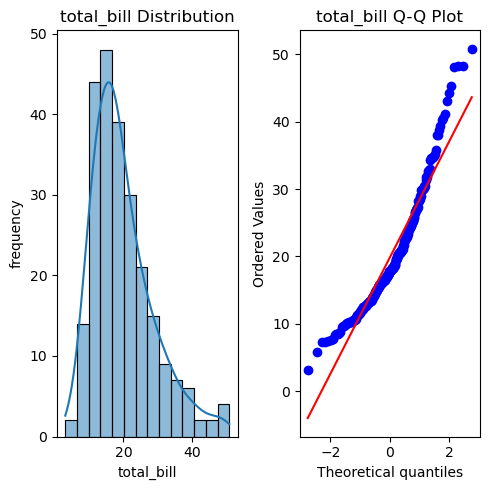

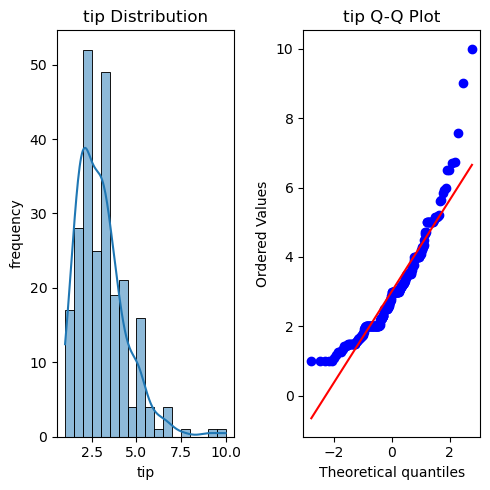

In [18]:
cols = ['total_bill', 'tip']
#size feature is numerical but i didn't include it here since it has low cardinality 6 values atmost
for feature in cols:
    fig, axes = plt.subplots(1,2, figsize=(5,5))

    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f'{feature} Distribution')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('frequency')

    probplot(df[feature], dist="norm", plot=axes[1])
    axes[1].set_title(f'{feature} Q-Q Plot')

    plt.tight_layout()
    plt.show()

Scaling

In [20]:
#we have to scale the total_bill and tips since it doesn't revolve on the same range
#Standard Scaler would be the best choice since according the plot above it has a bell curve like distribution and also these features are unbounded

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

In [24]:
scaled_values = scaler.fit_transform(df[cols])

In [30]:
scaled = pd.DataFrame(scaled_values, columns = [f'{col}_scaled' for col in cols])

In [31]:
df_scaled = pd.concat([df.drop(columns=cols), scaled], axis=1)

In [33]:
df_scaled.head()

,sex,smoker,day,time,size,total_bill_scaled,tip_scaled
0,Female,No,Sun,Dinner,2.0,-0.317584,-1.441513
1,Male,No,Sun,Dinner,3.0,-1.065471,-0.971231
2,Male,No,Sun,Dinner,3.0,0.134522,0.360029
3,Male,No,Sun,Dinner,2.0,0.434801,0.222561
4,Female,No,Sun,Dinner,4.0,0.537144,0.439615


In [34]:
df.describe()

,total_bill,tip,size
count,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016
std,8.910071,1.385002,0.952356
min,3.070000,1.000000,1.000000
25%,13.380000,2.000000,2.000000
50%,17.810000,2.920000,2.000000
75%,24.175000,3.575000,3.000000
max,50.810000,10.000000,6.000000
